##Task-10: Correlation Analysis

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploads = files.upload()
df = pd.read_csv("Data_set 2 - Copy.csv")
df

Saving Data_set 2 - Copy.csv to Data_set 2 - Copy.csv


,gender,age,Investment_Avenues,Mutual_Funds,Equity_Market,Debentures,Government_Bonds,Fixed_Deposits,PPF,Gold,...,Duration,Invest_Monitor,Expect,Avenue,What are your savings objectives?,Reason_Equity,Reason_Mutual,Reason_Bonds,Reason_FD,Source
0,Female,34,Yes,1,2,5,3,7,6,4,...,1-3 years,Monthly,20%-30%,Mutual Fund,Retirement Plan,Capital Appreciation,Better Returns,Safe Investment,Fixed Returns,Newspapers and Magazines
1,Female,23,Yes,4,3,2,1,5,6,7,...,More than 5 years,Weekly,20%-30%,Mutual Fund,Health Care,Dividend,Better Returns,Safe Investment,High Interest Rates,Financial Consultants
2,Male,30,Yes,3,6,4,2,5,1,7,...,3-5 years,Daily,20%-30%,Equity,Retirement Plan,Capital Appreciation,Tax Benefits,Assured Returns,Fixed Returns,Television
3,Male,22,Yes,2,1,3,7,6,4,5,...,Less than 1 year,Daily,10%-20%,Equity,Retirement Plan,Dividend,Fund Diversification,Tax Incentives,High Interest Rates,Internet
4,Female,24,No,2,1,3,6,4,5,7,...,Less than 1 year,Daily,20%-30%,Equity,Retirement Plan,Capital Appreciation,Better Returns,Safe Investment,Risk Free,Internet
5,Female,24,No,7,5,4,6,3,1,2,...,1-3 years,Daily,30%-40%,Mutual Fund,Retirement Plan,Liquidity,Fund Diversification,Safe Investment,Risk Free,Internet
6,Female,27,Yes,3,6,4,2,5,1,7,...,3-5 years,Monthly,20%-30%,Equity,Retirement Plan,Capital Appreciation,Better Returns,Assured Returns,High Interest Rates,Financial Consultants
7,Male,21,Yes,2,3,7,4,6,1,5,...,3-5 years,Monthly,20%-30%,Mutual Fund,Retirement Plan,Capital Appreciation,Better Returns,Assured Returns,Risk Free,Newspapers and Magazines
8,Male,35,Yes,2,4,7,5,3,1,6,...,1-3 years,Weekly,20%-30%,Equity,Retirement Plan,Capital Appreciation,Fund Diversification,Safe Investment,Fixed Returns,Television
9,Male,31,Yes,1,3,7,4,5,2,6,...,3-5 years,Monthly,30%-40%,Fixed Deposits,Retirement Plan,Capital Appreciation,Fund Diversification,Assured Returns,Fixed Returns,Newspapers and Magazines


In [ ]:
duration_mapping = {
    "Less than 1 year": 0.5,
    "1-3 years": 2,
    "3-5 years": 4,
    "More than 5 years": 6
}
df["Numeric_Duration"] = df["Duration"].map(duration_mapping)

In [ ]:
print(duration_mapping)

{'Less than 1 year': 0.5, '1-3 years': 2, '3-5 years': 4, 'More than 5 years': 6}


In [ ]:
expect_mapping = {
    "10%-20%": 15,
    "20%-30%": 25,
    "30%-40%": 35
}
df["Numeric_Expect"] = df["Expect"].map(expect_mapping)

In [ ]:
# Map 'Investment_Avenues' (Yes/No) to 1/0
df["Investment_Avenues_Numeric"] = df["Investment_Avenues"].map({"Yes": 1, "No": 0})

# Map 'Stock_Marktet' (Yes/No) to 1/0
df["Stock_Marktet_Numeric"] = df["Stock_Marktet"].map({"Yes": 1, "No": 0})

In [ ]:
correlation_data = df[["age", "Numeric_Duration", "Numeric_Expect", "Investment_Avenues_Numeric", "Stock_Marktet_Numeric"]]

Correlation Matrix:
                                 age  Numeric_Duration  Numeric_Expect  \
age                         1.000000          0.051756       -0.089606   
Numeric_Duration            0.051756          1.000000        0.258223   
Numeric_Expect             -0.089606          0.258223        1.000000   
Investment_Avenues_Numeric  0.388769          0.347373       -0.181541   
Stock_Marktet_Numeric       0.430033          0.148487        0.042524   

                            Investment_Avenues_Numeric  Stock_Marktet_Numeric  
age                                           0.388769               0.430033  
Numeric_Duration                              0.347373               0.148487  
Numeric_Expect                               -0.181541               0.042524  
Investment_Avenues_Numeric                    1.000000               0.753371  
Stock_Marktet_Numeric                         0.753371               1.000000  


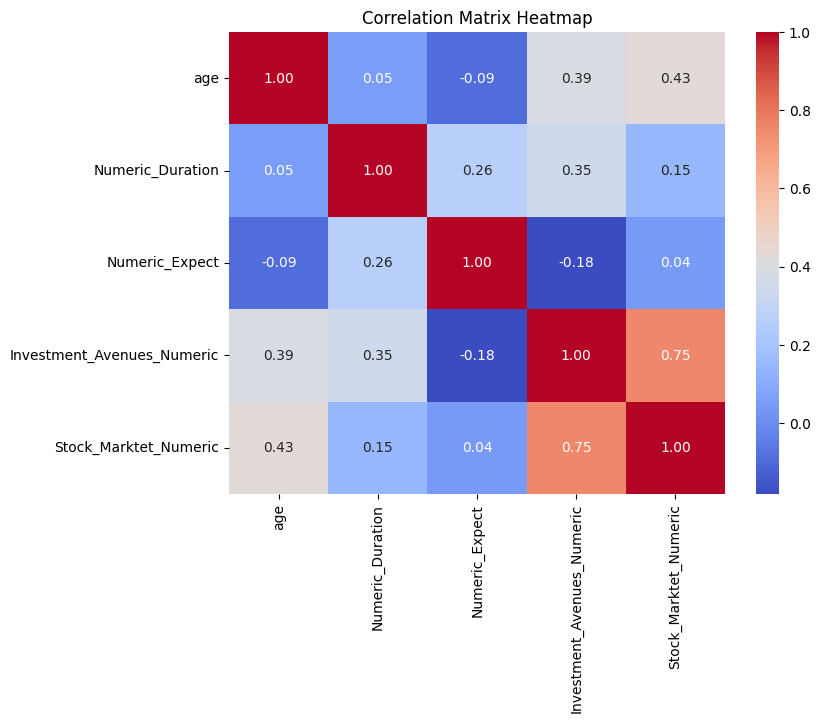

In [ ]:
correlation_matrix = correlation_data.corr()
print("Correlation Matrix:")
print(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

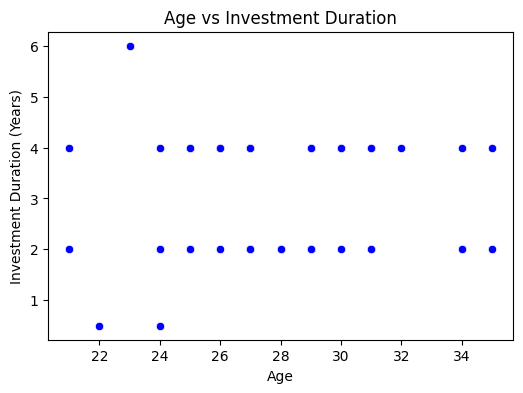

In [ ]:
# Age vs Numeric Duration
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="age", y="Numeric_Duration", color="blue")
plt.title("Age vs Investment Duration")
plt.xlabel("Age")
plt.ylabel("Investment Duration (Years)")
plt.show()

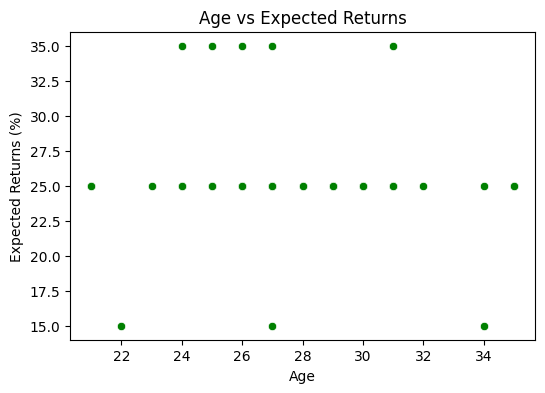

In [ ]:
# Age vs Expected Returns
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="age", y="Numeric_Expect", color="green")
plt.title("Age vs Expected Returns")
plt.xlabel("Age")
plt.ylabel("Expected Returns (%)")
plt.show()

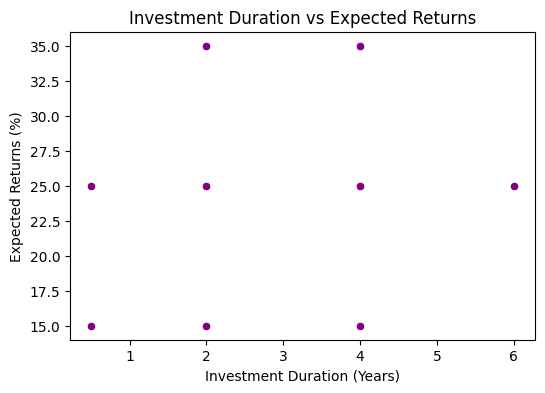

In [ ]:
# Numeric Duration vs Expected Returns
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="Numeric_Duration", y="Numeric_Expect", color="purple")
plt.title("Investment Duration vs Expected Returns")
plt.xlabel("Investment Duration (Years)")
plt.ylabel("Expected Returns (%)")
plt.show()